# 0. Importacion de librerias

In [2]:
# Sección 1: Librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio  # para leer mapas de elevación
import geopandas as gpd
from shapely.geometry import Point, Polygon
import folium  # para visualizar mapas interactivos


In [73]:
!pip install contextily


In [79]:
import contextily as ctx


# 1. Analisis de Elevación de la zona

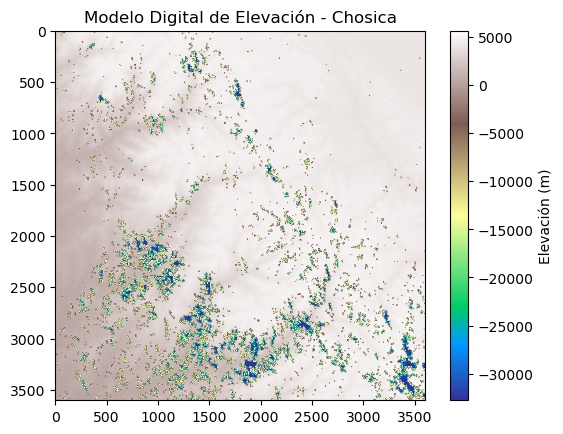

In [6]:
import rasterio
import matplotlib.pyplot as plt

# Elevación
with rasterio.open("../data/dem_chosica.tif") as dem:
    elev = dem.read(1)
    plt.imshow(elev, cmap='terrain')
    plt.colorbar(label='Elevación (m)')
    plt.title('Modelo Digital de Elevación - Chosica')
    plt.show()


# 2. Analisis de la vegetación de la zona

Tamaño del raster: (1671, 1671)
Valor mínimo: -0.1296403
Valor máximo: 0.5695002
Pixeles válidos: 2792241


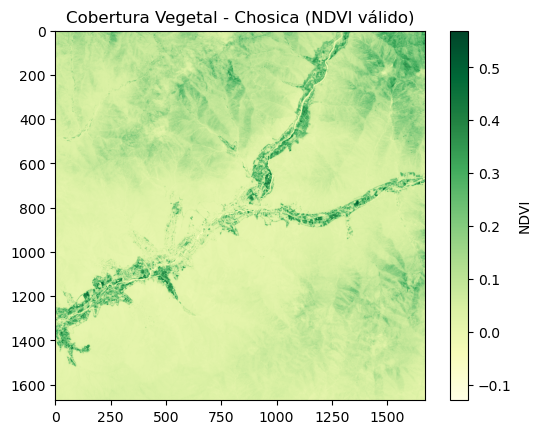

In [36]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# Ruta al archivo nuevo
ndvi_path = "../data/vegetacion_chosica/ndvi_sentinel_chosica2.tif"

with rasterio.open(ndvi_path) as src:
    ndvi = src.read(1).astype(np.float32)
    profile = src.profile
    bounds = src.bounds
    transform = src.transform

# Mostrar información
print("Tamaño del raster:", ndvi.shape)
print("Valor mínimo:", np.nanmin(ndvi))
print("Valor máximo:", np.nanmax(ndvi))

# Enmascarar valores no válidos (por ejemplo NDVI < -0.2 o > 1.0)
ndvi_clean = np.where((ndvi < -0.2) | (ndvi > 1.0), np.nan, ndvi)
print("Pixeles válidos:", np.sum(~np.isnan(ndvi_clean)))

# Visualización
plt.imshow(ndvi_clean, cmap='YlGn')
plt.colorbar(label="NDVI")
plt.title("Cobertura Vegetal - Chosica (NDVI válido)")
plt.show()

# 3. Analisis de los tipos de suelos de la zona

Tipos de suelo únicos: ['Grava bien graduada con arena' 'Grava mal graduda con arena'
 'Grava mal graduada con limo' 'Arena mal graduada' 'Arena limosa'
 'Arena arcillosa con limo' 'Arena mal graduada con limo']


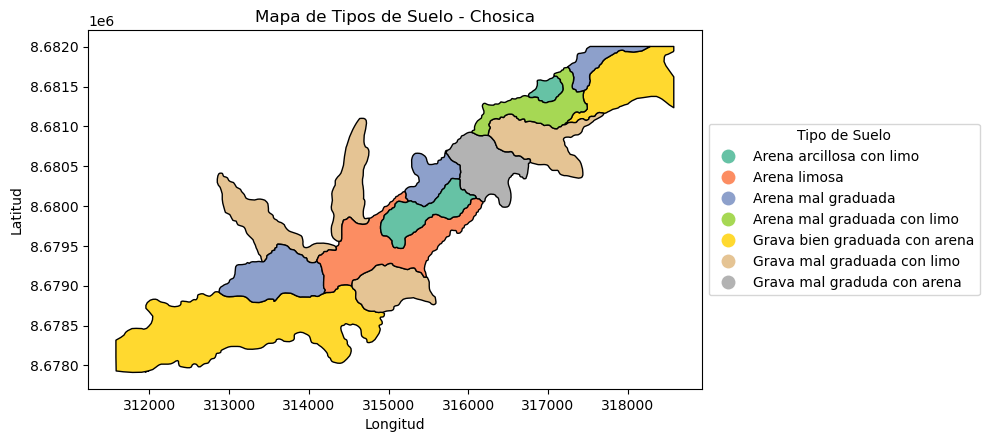

In [42]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Cargar el shapefile
suelos = gpd.read_file("../data/suelos_chosica/Suelos.shp")

# Mostrar los tipos únicos de suelo
print("Tipos de suelo únicos:", suelos["Tipo"].unique())

# Crear figura y ejes personalizados
fig, ax = plt.subplots(figsize=(10, 8))

# Graficar
suelos.plot(
    column="Tipo",
    legend=True,
    cmap="Set2",
    edgecolor="black",
    ax=ax,
    legend_kwds={
        'loc': 'center left',       # Posición
        'bbox_to_anchor': (1, 0.5), # Afuera del eje: (x=1 es justo al borde derecho, 0.5 es verticalmente centrado)
        'title': 'Tipo de Suelo'    # Título para la leyenda
    }
)

# Añadir título y etiquetas
ax.set_title("Mapa de Tipos de Suelo - Chosica")
ax.set_xlabel("Longitud")
ax.set_ylabel("Latitud")

# Ajustar para que no se corte la leyenda
plt.tight_layout()
plt.show()




# 4. Analisis de la lluvia acumulada en la zona

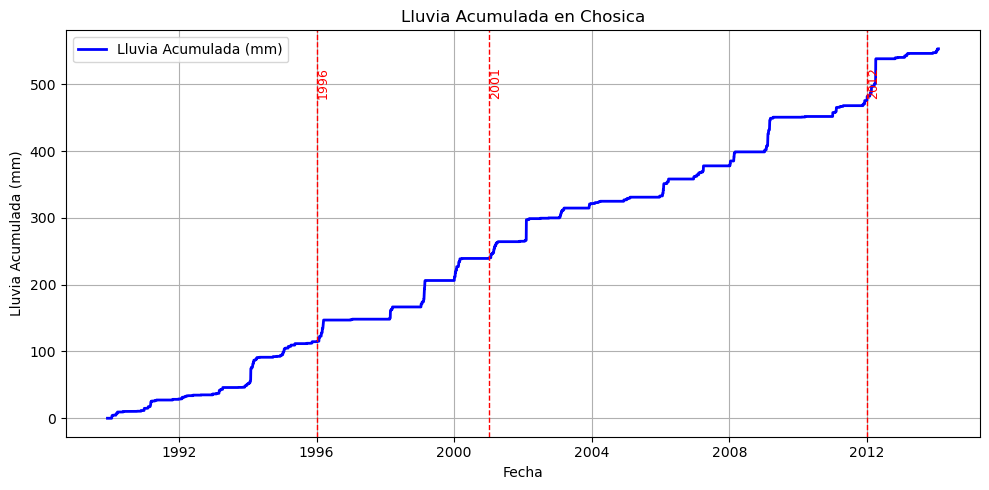

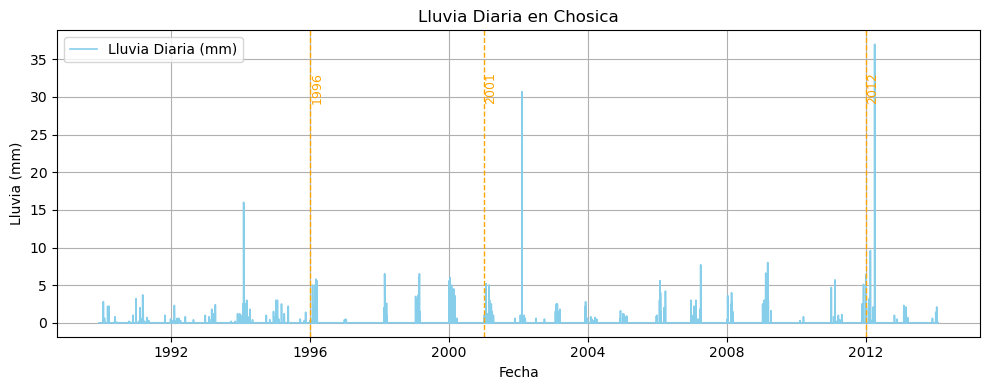

In [60]:
import pandas as pd
import matplotlib.pyplot as plt

# Leer el archivo de lluvia
df_lluvia = pd.read_csv("../data/lluvia_chosica.txt", sep=r'\s+', header=None,
                        names=["year", "month", "day", "lluvia_mm", "col5", "col6"])

# Crear columna de fecha
df_lluvia["fecha"] = pd.to_datetime(df_lluvia[["year", "month", "day"]])

# Filtrar valores válidos
df_lluvia = df_lluvia[df_lluvia["lluvia_mm"] >= 0]

# Calcular lluvia acumulada
df_lluvia["lluvia_acumulada"] = df_lluvia["lluvia_mm"].cumsum()

# Años clave a resaltar (puedes agregar o quitar)
anios_clave = [1996, 2001, 2012]

# --- PRIMER GRÁFICO: LLUVIA ACUMULADA ---
plt.figure(figsize=(10, 5))
plt.plot(df_lluvia["fecha"], df_lluvia["lluvia_acumulada"], color='blue', linewidth=2, label="Lluvia Acumulada (mm)")

# Marcar años clave
for anio in anios_clave:
    fecha_clave = pd.Timestamp(f"{anio}-01-01")
    plt.axvline(x=fecha_clave, color='red', linestyle='--', linewidth=1)
    plt.text(fecha_clave, df_lluvia["lluvia_acumulada"].max() * 0.95, str(anio),
             rotation=90, color='red', fontsize=9, verticalalignment='top')

plt.title("Lluvia Acumulada en Chosica")
plt.xlabel("Fecha")
plt.ylabel("Lluvia Acumulada (mm)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# --- SEGUNDO GRÁFICO: LLUVIA DIARIA ---
plt.figure(figsize=(10, 4))
plt.plot(df_lluvia["fecha"], df_lluvia["lluvia_mm"], color='skyblue', linewidth=1.2, label="Lluvia Diaria (mm)")

# Marcar años clave
for anio in anios_clave:
    fecha_clave = pd.Timestamp(f"{anio}-01-01")
    plt.axvline(x=fecha_clave, color='orange', linestyle='--', linewidth=1)
    plt.text(fecha_clave, df_lluvia["lluvia_mm"].max() * 0.9, str(anio),
             rotation=90, color='orange', fontsize=9, verticalalignment='top')

plt.title("Lluvia Diaria en Chosica")
plt.xlabel("Fecha")
plt.ylabel("Lluvia (mm)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()



# 5. Creación de las zonas seguras en .csv

In [99]:
import rasterio
import numpy as np
from rasterio.warp import reproject, Resampling
from rasterio.features import shapes
import geopandas as gpd
from shapely.geometry import shape
import pandas as pd

# 1. Cargar DEM y NDVI
with rasterio.open("../data/dem_chosica.tif") as dem_src:
    dem = dem_src.read(1)
    dem_transform = dem_src.transform
    dem_crs = dem_src.crs
    dem_meta = dem_src.meta.copy()

with rasterio.open("../data/vegetacion_chosica/ndvi_sentinel_chosica2.tif") as ndvi_src:
    ndvi_original = ndvi_src.read(1)
    ndvi_transform = ndvi_src.transform
    ndvi_crs = ndvi_src.crs

    # Reescalar NDVI al tamaño del DEM
    ndvi_resampled = np.empty_like(dem, dtype=np.float32)
    reproject(
        source=ndvi_original,
        destination=ndvi_resampled,
        src_transform=ndvi_transform,
        src_crs=ndvi_crs,
        dst_transform=dem_transform,
        dst_crs=dem_crs,
        resampling=Resampling.bilinear
    )

# 2. Simular zona de impacto como buffer cuadrado central
center = (dem.shape[1] // 2, dem.shape[0] // 2)
impacto_mask = np.zeros_like(dem, dtype=bool)
impacto_mask[center[1]-250:center[1]+250, center[0]-250:center[0]+250] = True

# 3. Definir umbrales
umbral_altura = 1000
umbral_ndvi = 0.2

# 4. Máscara de zonas seguras
mascara_segura = (dem > umbral_altura) & (ndvi_resampled > umbral_ndvi) & (~impacto_mask)

# 5. Convertir máscara a geometrías
resultados = shapes(mascara_segura.astype(np.uint8), mask=mascara_segura, transform=dem_transform)
geometries = [shape(geom) for geom, value in resultados if value == 1]
zonas_seguras_gdf = gpd.GeoDataFrame(geometry=geometries, crs=dem_crs)

# 6. Extraer centroides y exportar CSV
zonas_seguras_gdf = zonas_seguras_gdf.to_crs("EPSG:32718")
centroides = zonas_seguras_gdf.geometry.centroid.to_crs("EPSG:4326")
df_centroides = pd.DataFrame({
    "lat": centroides.y,
    "lon": centroides.x
})
csv_path = "../data/zonas_seguras/zonas_seguras_potenciales.csv"
df_centroides.to_csv(csv_path, index=False)

print("✅ Zonas seguras guardadas en:", csv_path)


✅ Zonas seguras guardadas en: ../data/zonas_seguras/zonas_seguras_potenciales.csv


# 6. Gráfico de las zonas Seguras por criterios sugeridos

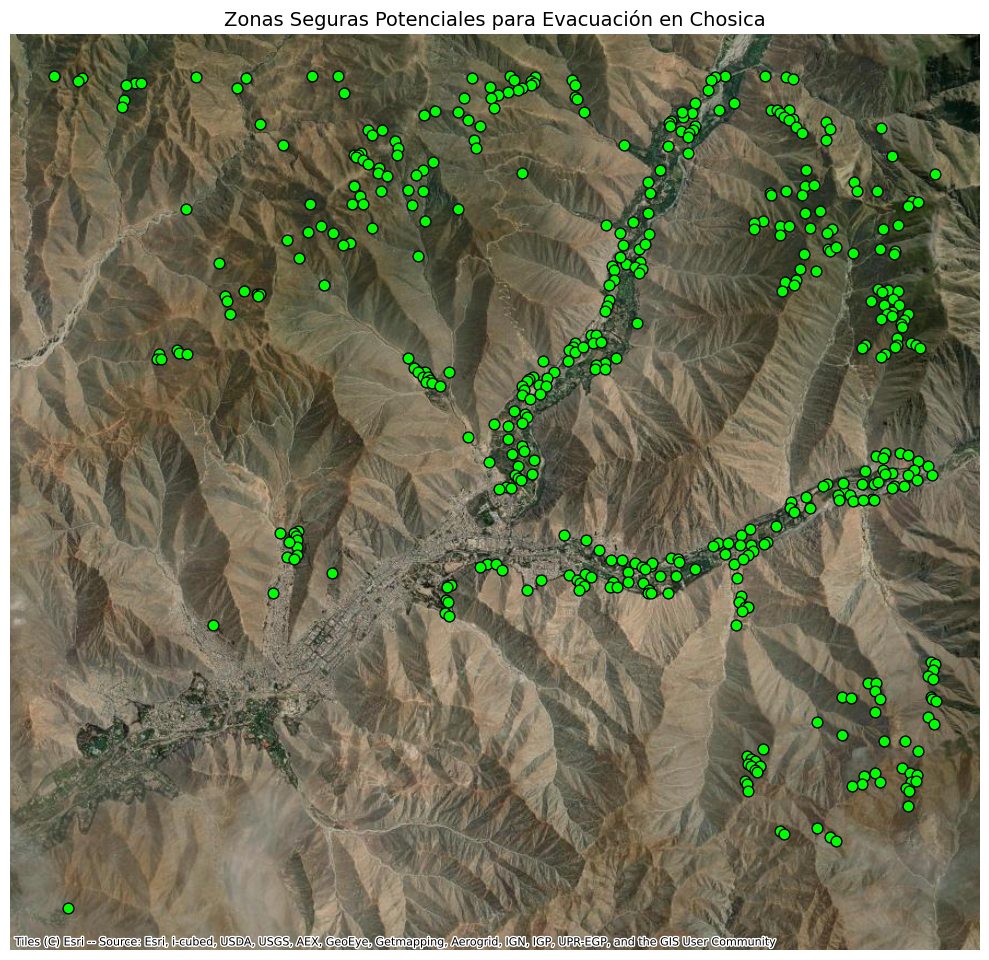

In [107]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import contextily as ctx
from shapely.geometry import Point

# 1. Leer coordenadas desde el archivo CSV
df_zonas = pd.read_csv("../data/zonas_seguras/zonas_seguras_potenciales.csv")

# 2. Crear geometrías (puntos) a partir de latitud y longitud
geometry = [Point(xy) for xy in zip(df_zonas["lon"], df_zonas["lat"])]
gdf_zonas = gpd.GeoDataFrame(df_zonas, geometry=geometry, crs="EPSG:4326")

# 3. Proyectar a Web Mercator (compatible con contextily)
gdf_zonas_mercator = gdf_zonas.to_crs(epsg=3857)

# 4. Crear figura
fig, ax = plt.subplots(figsize=(10, 10))

# 5. Dibujar zonas seguras
gdf_zonas_mercator.plot(ax=ax, color="lime", edgecolor="black", markersize=60)

# 6. Agregar fondo satelital
ctx.add_basemap(ax, source=ctx.providers.Esri.WorldImagery)

# 7. Personalización
ax.set_title("Zonas Seguras Potenciales para Evacuación en Chosica", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()


In [117]:
import pandas as pd
import numpy as np

# Coordenadas de referencia aproximadas de Chosica (centro y quebradas aledañas)
# Rango de latitudes y longitudes basado en zonas vulnerables
np.random.seed(42)  # Para reproducibilidad

# Generar 100 puntos de alerta distribuidos en el rango real de Chosica
longitudes = np.random.uniform(-76.75, -76.65, 100)
latitudes = np.random.uniform(-11.95, -11.90, 100)

# Crear DataFrame con los puntos de alerta
df_alertas = pd.DataFrame({
    "id_alerta": range(1, 101),
    "longitud": longitudes,
    "latitud": latitudes,
    "fuente": np.random.choice(["ciudadano", "camara"], size=100, p=[0.7, 0.3])
})

# Guardar como CSV
ruta_csv = "../data/puntos_alerta/puntos_alerta_ejemplo.csv"
import os
os.makedirs(os.path.dirname(ruta_csv), exist_ok=True)
df_alertas.to_csv(ruta_csv, index=False)

print(f"✅ Archivo guardado en: {ruta_csv}")
df_alertas.head()


✅ Archivo guardado en: ../data/puntos_alerta/puntos_alerta_ejemplo.csv


,id_alerta,longitud,latitud,fuente
0,1,-76.712546,-11.948429,ciudadano
1,2,-76.654929,-11.918179,ciudadano
2,3,-76.676801,-11.934282,ciudadano
3,4,-76.690134,-11.924571,camara
4,5,-76.734398,-11.904622,ciudadano


In [127]:
import os

# Crear carpeta si no existe
output_dir = "../data/zonas_afectadas"
os.makedirs(output_dir, exist_ok=True)


In [129]:
gdf_zona_max.to_file(os.path.join(output_dir, "zona_maxima.shp"))
gdf_zona_min.to_file(os.path.join(output_dir, "zona_minima.shp"))


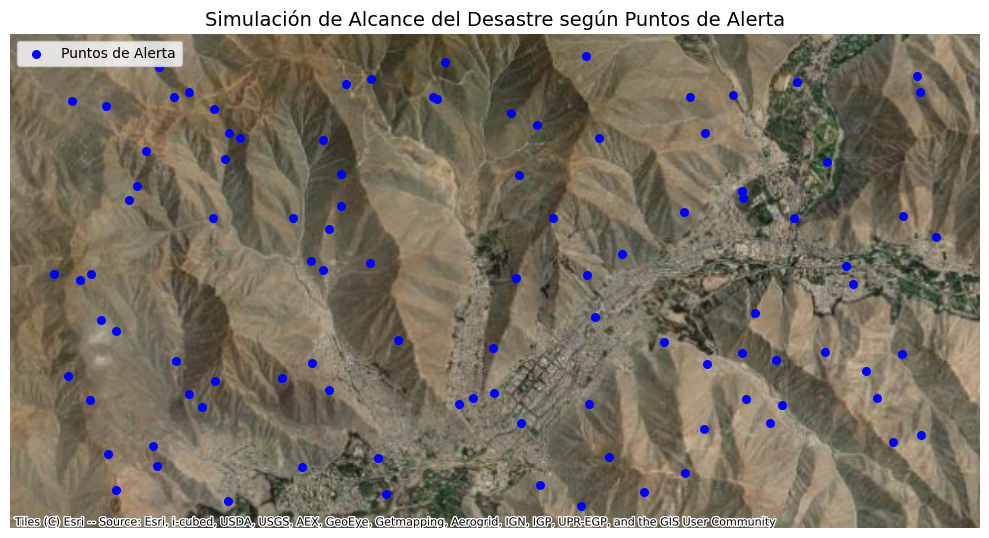

In [135]:
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
import rasterio
from shapely.geometry import Point, Polygon
from rasterio.plot import show
from scipy.ndimage import gaussian_filter
from rasterio.features import shapes
import pandas as pd

# 1. Cargar el DEM
dem_path = "../data/dem_chosica.tif"
with rasterio.open(dem_path) as src:
    dem = src.read(1)
    transform = src.transform
    crs = src.crs

# 2. Cargar puntos de alerta desde CSV
csv_alertas = "../data/puntos_alerta/puntos_alerta_ejemplo.csv"
df_alertas = pd.read_csv(csv_alertas)

# Crear geometrías desde columnas 'longitud' y 'latitud'
geometry = [Point(xy) for xy in zip(df_alertas['longitud'], df_alertas['latitud'])]
gdf_alertas = gpd.GeoDataFrame(df_alertas, geometry=geometry, crs="EPSG:4326")

# Reproyectar a la proyección del DEM
gdf_alertas = gdf_alertas.to_crs(crs)

# 3. Crear raster vacío e inicializar núcleos de alerta
impacto = np.zeros_like(dem)

for punto in gdf_alertas.geometry:
    col, row = ~transform * (punto.x, punto.y)
    col, row = int(col), int(row)
    if 0 <= row < impacto.shape[0] and 0 <= col < impacto.shape[1]:
        impacto[row, col] = 1

# 4. Simular propagación del desastre
zona_afectada = gaussian_filter(impacto, sigma=25)

# 5. Umbrales mínimo y máximo para visualización
umbral_min = 0.01
umbral_max = 0.1

zona_min = (zona_afectada > umbral_min).astype(np.uint8)
zona_max = (zona_afectada > umbral_max).astype(np.uint8)

# 6. Extraer polígonos
def extraer_poligonos(zona_binaria):
    zonas = []
    for shape, value in shapes(zona_binaria, mask=zona_binaria.astype(bool), transform=transform):
        if value == 1:
            zonas.append(Polygon(shape["coordinates"][0]))
    return zonas

poligonos_min = extraer_poligonos(zona_min)
poligonos_max = extraer_poligonos(zona_max)

gdf_zona_min = gpd.GeoDataFrame(geometry=poligonos_min, crs=crs)
gdf_zona_max = gpd.GeoDataFrame(geometry=poligonos_max, crs=crs)

# 7. Guardar zona afectada como shapefile
gdf_zona_max.to_file("../data/zonas_afectadas/zona_maxima.shp")
gdf_zona_min.to_file("../data/zonas_afectadas/zona_minima.shp")

# 8. Graficar todo
fig, ax = plt.subplots(figsize=(10, 10))

# Graficar solo si tiene geometría válida
if not gdf_zona_min.empty:
    gdf_zona_min.boundary.plot(ax=ax, color="orange", linestyle="--", label="Zona mínima")

if not gdf_zona_max.empty:
    gdf_zona_max.boundary.plot(ax=ax, color="red", label="Zona máxima")

gdf_alertas.plot(ax=ax, color="blue", markersize=30, label="Puntos de Alerta")

ctx.add_basemap(ax, crs=gdf_alertas.crs.to_string(), source=ctx.providers.Esri.WorldImagery)

ax.set_title("Simulación de Alcance del Desastre según Puntos de Alerta", fontsize=14)
ax.legend(loc="upper left")
ax.set_axis_off()
plt.tight_layout()
plt.show()



In [137]:
pip install xlrd


   ---------------------------------------- 0.0/96.5 kB ? eta -:--:--
   ---- ----------------------------------- 10.2/96.5 kB ? eta -:--:--
   ------------------------- -------------- 61.4/96.5 kB 648.1 kB/s eta 0:00:01
   ---------------------------------------- 96.5/96.5 kB 784.5 kB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [159]:
# Verificar los límites del raster DEM
bounds = rasterio.transform.array_bounds(dem.shape[0], dem.shape[1], transform)
print("📌 Límites del DEM (xmin, ymin, xmax, ymax):", bounds)

# Revisar si los puntos están dentro de esos límites
for i, punto in enumerate(gdf_alertas_total.geometry):
    x, y = punto.x, punto.y
    dentro = bounds[0] <= x <= bounds[2] and bounds[1] <= y <= bounds[3]
    print(f"🔎 Punto {i+1}: ({x:.2f}, {y:.2f}) {'✅ dentro' if dentro else '❌ fuera'} del DEM")


📌 Límites del DEM (xmin, ymin, xmax, ymax): (-77.00013888888888, -12.000138888888891, -75.9998611111111, -10.999861111111112)
🔎 Punto 1: (-76.71, -11.95) ✅ dentro del DEM
🔎 Punto 2: (-76.65, -11.92) ✅ dentro del DEM
🔎 Punto 3: (-76.68, -11.93) ✅ dentro del DEM
🔎 Punto 4: (-76.69, -11.92) ✅ dentro del DEM
🔎 Punto 5: (-76.73, -11.90) ✅ dentro del DEM
🔎 Punto 6: (-76.73, -11.94) ✅ dentro del DEM
🔎 Punto 7: (-76.74, -11.93) ✅ dentro del DEM
🔎 Punto 8: (-76.66, -11.91) ✅ dentro del DEM
🔎 Punto 9: (-76.69, -11.94) ✅ dentro del DEM
🔎 Punto 10: (-76.68, -11.95) ✅ dentro del DEM
🔎 Punto 11: (-76.75, -11.94) ✅ dentro del DEM
🔎 Punto 12: (-76.65, -11.94) ✅ dentro del DEM
🔎 Punto 13: (-76.67, -11.90) ✅ dentro del DEM
🔎 Punto 14: (-76.73, -11.91) ✅ dentro del DEM
🔎 Punto 15: (-76.73, -11.92) ✅ dentro del DEM
🔎 Punto 16: (-76.73, -11.91) ✅ dentro del DEM
🔎 Punto 17: (-76.72, -11.91) ✅ dentro del DEM
🔎 Punto 18: (-76.70, -11.94) ✅ dentro del DEM
🔎 Punto 19: (-76.71, -11.91) ✅ dentro del DEM
🔎 Punto 2

In [161]:
# Inicializar nuevamente el raster de impacto
impacto = np.zeros_like(dem)

# Revisar cada punto y su proyección a índice de pixel
print("🧪 Revisando puntos en el raster DEM:")
activados = 0
for i, punto in enumerate(gdf_alertas_total.geometry):
    x, y = punto.x, punto.y
    col, row = ~transform * (x, y)
    col, row = int(col), int(row)

    if 0 <= row < impacto.shape[0] and 0 <= col < impacto.shape[1]:
        impacto[row, col] = 1
        activados += 1
        print(f"✅ Punto {i+1} activado en raster en (col={col}, row={row})")
    else:
        print(f"❌ Punto {i+1} fuera del raster (col={col}, row={row})")

print(f"🔢 Total de píxeles activados: {activados}")


🧪 Revisando puntos en el raster DEM:
✅ Punto 1 activado en raster en (col=1035, row=3414)
✅ Punto 2 activado en raster en (col=1242, row=3305)
✅ Punto 3 activado en raster en (col=1164, row=3363)
✅ Punto 4 activado en raster en (col=1116, row=3328)
✅ Punto 5 activado en raster en (col=956, row=3257)
✅ Punto 6 activado en raster en (col=956, row=3375)
✅ Punto 7 activado en raster en (col=921, row=3346)
✅ Punto 8 activado en raster en (col=1212, row=3284)
✅ Punto 9 activado en raster en (col=1116, row=3379)
✅ Punto 10 activado en raster en (col=1155, row=3406)
✅ Punto 11 activado en raster en (col=907, row=3368)
✅ Punto 12 activado en raster en (col=1249, row=3391)
✅ Punto 13 activado en raster en (col=1200, row=3253)
✅ Punto 14 activado en raster en (col=976, row=3275)
✅ Punto 15 activado en raster en (col=965, row=3306)
✅ Punto 16 activado en raster en (col=966, row=3263)
✅ Punto 17 activado en raster en (col=1010, row=3275)
✅ Punto 18 activado en raster en (col=1089, row=3386)
✅ Punto

In [163]:
# 5. Simular la propagación del desastre (difusión con filtro gaussiano)
zona_afectada = gaussian_filter(impacto, sigma=10)  # antes estaba en 25

# 6. Umbral para definir zona afectada real
umbral = 0.001  # antes era 0.01
zona_binaria = (zona_afectada > umbral).astype(np.uint8)


In [165]:
print(f"🔥 Valor máximo tras filtro Gaussiano: {zona_afectada.max():.6f}")


🔥 Valor máximo tras filtro Gaussiano: 0.000000


In [167]:
print("🔢 Total de valores no cero en 'impacto':", np.count_nonzero(impacto))
print("📈 Máximo valor en 'impacto':", impacto.max())


🔢 Total de valores no cero en 'impacto': 100
📈 Máximo valor en 'impacto': 1


📊 Total de valores no cero en impacto: 3
🔥 Valor máximo tras filtro: 0.001592


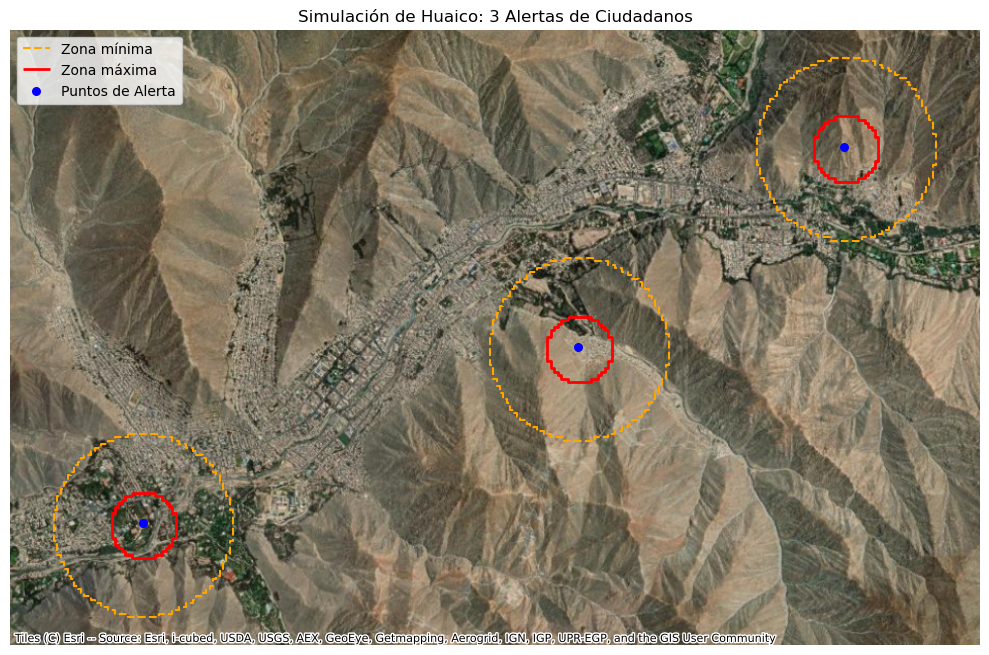

✅ Zonas afectadas guardadas:
🟠 ../results/zonas_afectadas\alerta_ciudadanos_20250413_215216_zona_minima.geojson
🔴 ../results/zonas_afectadas\alerta_ciudadanos_20250413_215216_zona_maxima.geojson
📊 Total de valores no cero en impacto: 1
🔥 Valor máximo tras filtro: 0.001592


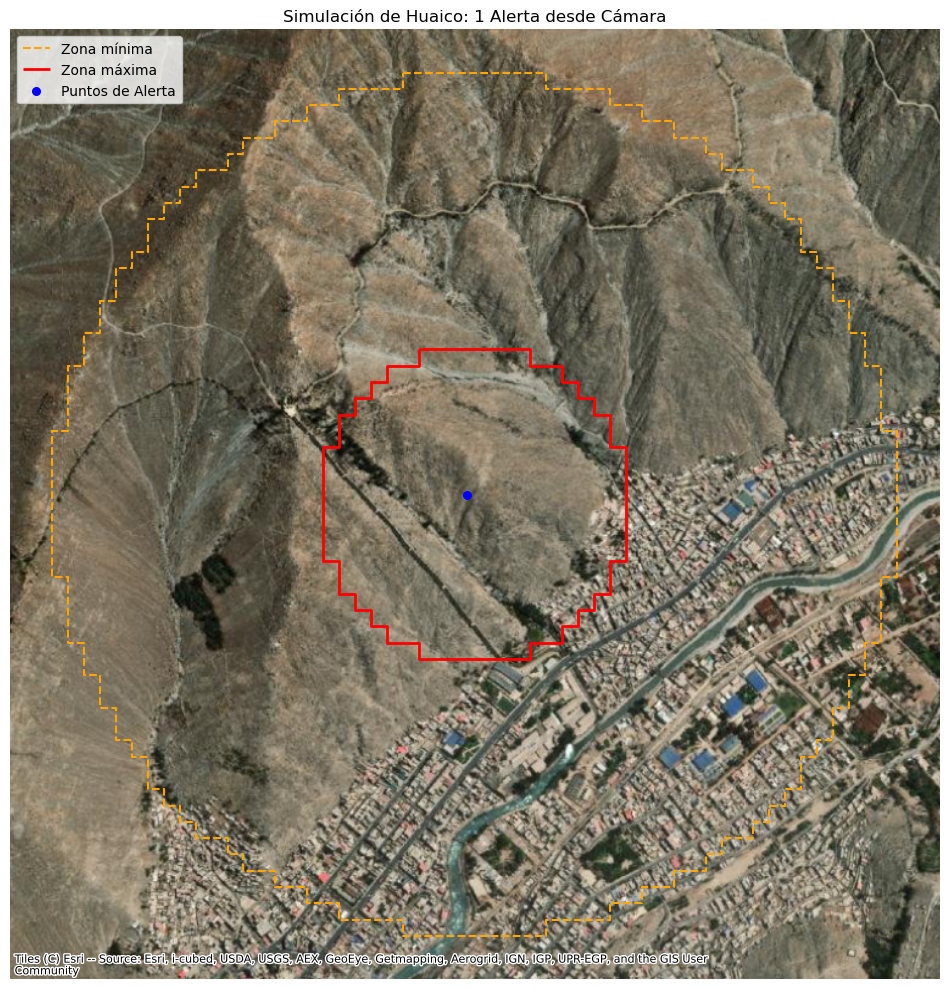

✅ Zonas afectadas guardadas:
🟠 ../results/zonas_afectadas\alerta_camara_20250413_215217_zona_minima.geojson
🔴 ../results/zonas_afectadas\alerta_camara_20250413_215217_zona_maxima.geojson


In [225]:
import numpy as np
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import contextily as ctx
import rasterio
from shapely.geometry import Point, Polygon
from scipy.ndimage import gaussian_filter
from rasterio.features import shapes
from datetime import datetime
import os

# 1. Cargar DEM
dem_path = "../data/dem_chosica.tif"
with rasterio.open(dem_path) as src:
    dem = src.read(1)
    transform = src.transform
    crs = src.crs

# 2. Cargar puntos de alerta
df = pd.read_csv("../data/puntos_alerta/puntos_alerta_ejemplo.csv")
geometry = gpd.points_from_xy(df["longitud"], df["latitud"])
gdf_alertas_total = gpd.GeoDataFrame(df, geometry=geometry, crs="EPSG:4326").to_crs(crs)

# 3. Función para simular desastre y guardar zonas afectadas
def simular_desastre_y_guardar(gdf_alertas, nombre_base, titulo="Simulación"):
    impacto = np.zeros_like(dem, dtype=np.float32)

    for punto in gdf_alertas.geometry:
        col, row = ~transform * (punto.x, punto.y)
        col, row = int(round(col)), int(round(row))
        if 0 <= row < impacto.shape[0] and 0 <= col < impacto.shape[1]:
            impacto[row, col] = 1

    print("📊 Total de valores no cero en impacto:", np.count_nonzero(impacto))
    zona_afectada = gaussian_filter(impacto, sigma=10)
    print(f"🔥 Valor máximo tras filtro: {zona_afectada.max():.6f}")

    umbral_min = 0.00005
    umbral_max = 0.001
    zona_binaria_min = (zona_afectada > umbral_min).astype(np.uint8)
    zona_binaria_max = (zona_afectada > umbral_max).astype(np.uint8)

    def extraer_poligonos(mask):
        return [
            Polygon(shape["coordinates"][0])
            for shape, val in shapes(mask, mask=mask.astype(bool), transform=transform)
            if val == 1
        ]

    poligonos_min = extraer_poligonos(zona_binaria_min)
    poligonos_max = extraer_poligonos(zona_binaria_max)

    if not poligonos_min or not poligonos_max:
        print(f"⚠️ No se generaron zonas válidas para graficar: {titulo}")
        return

    gdf_zona_min = gpd.GeoDataFrame(geometry=poligonos_min, crs=crs)
    gdf_zona_max = gpd.GeoDataFrame(geometry=poligonos_max, crs=crs)

    # 4. Visualización
    fig, ax = plt.subplots(figsize=(10, 10))
    gdf_zona_min.boundary.plot(ax=ax, color="orange", linestyle="--", linewidth=1.5, label="Zona mínima")
    gdf_zona_max.boundary.plot(ax=ax, color="red", linewidth=2, label="Zona máxima")
    gdf_alertas.plot(ax=ax, color="blue", markersize=30, label="Puntos de Alerta")
    ctx.add_basemap(ax, crs=gdf_alertas.crs.to_string(), source=ctx.providers.Esri.WorldImagery)
    ax.set_title(titulo)
    ax.axis("off")
    ax.legend(loc="upper left")
    plt.tight_layout()
    plt.show()

    # 5. Guardado de archivos con timestamp
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    output_dir = "../results/zonas_afectadas"
    os.makedirs(output_dir, exist_ok=True)

    geojson_min = os.path.join(output_dir, f"{nombre_base}_{timestamp}_zona_minima.geojson")
    geojson_max = os.path.join(output_dir, f"{nombre_base}_{timestamp}_zona_maxima.geojson")

    gdf_zona_min.to_file(geojson_min, driver="GeoJSON")
    gdf_zona_max.to_file(geojson_max, driver="GeoJSON")

    print(f"✅ Zonas afectadas guardadas:\n🟠 {geojson_min}\n🔴 {geojson_max}")

# 6. Pruebas específicas
ciudadanos = gdf_alertas_total[gdf_alertas_total["fuente"] == "ciudadano"].head(3)
camara = gdf_alertas_total[gdf_alertas_total["fuente"] == "camara"].head(1)

simular_desastre_y_guardar(ciudadanos, nombre_base="alerta_ciudadanos", titulo="Simulación de Huaico: 3 Alertas de Ciudadanos")
simular_desastre_y_guardar(camara, nombre_base="alerta_camara", titulo="Simulación de Huaico: 1 Alerta desde Cámara")


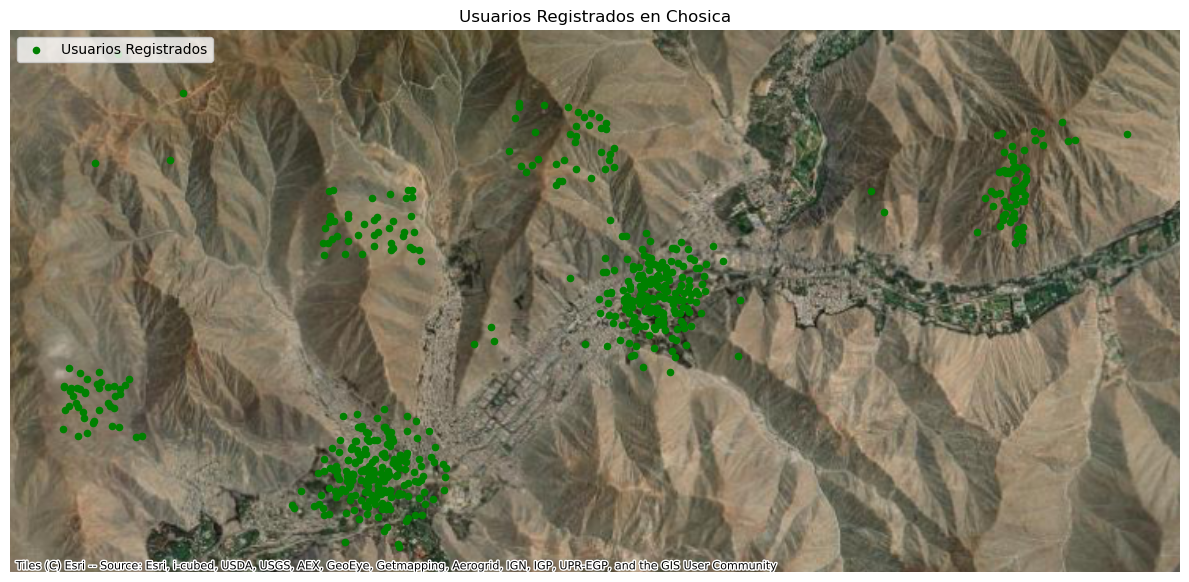

In [223]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
from shapely.geometry import Point

# Cargar el CSV actualizado con 600 usuarios reubicados
df = pd.read_csv("../data/usuarios/usuarios_registrados.csv")

# Crear geometría
geometry = [Point(xy) for xy in zip(df["longitud"], df["latitud"])]
gdf_usuarios = gpd.GeoDataFrame(df, geometry=geometry, crs="EPSG:4326")

# Visualización
fig, ax = plt.subplots(figsize=(12, 10))
gdf_usuarios.plot(ax=ax, color="green", markersize=20, label="Usuarios Registrados")
ctx.add_basemap(ax, crs=gdf_usuarios.crs.to_string(), source=ctx.providers.Esri.WorldImagery)
ax.set_title("Usuarios Registrados en Chosica")
ax.set_axis_off()
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()



In [235]:
import numpy as np
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import contextily as ctx
import rasterio
from shapely.geometry import Point
from datetime import datetime
import os
import glob

# === 1. Cargar usuarios registrados ===
df_usuarios = pd.read_csv("../data/usuarios/usuarios_registrados.csv")
geometry_u = gpd.points_from_xy(df_usuarios["longitud"], df_usuarios["latitud"])
gdf_usuarios = gpd.GeoDataFrame(df_usuarios, geometry=geometry_u, crs="EPSG:4326")

# === 2. Cargar puntos de alerta para graficarlos ===
df_alertas = pd.read_csv("../data/puntos_alerta/puntos_alerta_ejemplo.csv")
geometry = gpd.points_from_xy(df_alertas["longitud"], df_alertas["latitud"])
gdf_alertas_total = gpd.GeoDataFrame(df_alertas, geometry=geometry, crs="EPSG:4326")

# === 3. Buscar archivo zona máxima según fuente ===
def obtener_zona_maxima_mas_reciente(fuente="ciudadano"):
    carpeta = "../results/zonas_afectadas"
    prefijo = "alerta_ciudadanos" if fuente == "ciudadano" else "alerta_camara"
    patron = os.path.join(carpeta, f"{prefijo}_*zona_maxima.geojson")
    archivos = sorted(glob.glob(patron), key=os.path.getmtime, reverse=True)
    
    if not archivos:
        raise FileNotFoundError(f"❌ No se encontró ninguna zona máxima generada por {fuente}.")
    
    print(f"📂 Usando zona afectada más reciente: {archivos[0]}")
    return archivos[0]

# === 4. Alerta y visualización ===
def alertar_usuarios_desde_zona_maxima(fuente="ciudadano", nombre_csv="usuarios_a_alertar"):
    # Leer archivo zona máxima
    geojson_zona_max = obtener_zona_maxima_mas_reciente(fuente)
    gdf_zona_max = gpd.read_file(geojson_zona_max)

    # Asegurar que los CRS coincidan
    gdf_zona_max = gdf_zona_max.to_crs(gdf_usuarios.crs)

    # Detectar usuarios dentro de la zona afectada
    afectados = gpd.sjoin(gdf_usuarios, gdf_zona_max, how="inner", predicate="within")
    afectados["afectado"] = "sí"

    # === Visualización ===
    fig, ax = plt.subplots(figsize=(10, 10))
    gdf_usuarios.plot(ax=ax, color="green", markersize=10, label="Usuarios Registrados")
    afectados.plot(ax=ax, color="yellow", markersize=20, label="Usuarios Afectados")
    gdf_zona_max.plot(ax=ax, facecolor="none", edgecolor="red", linewidth=2, alpha=0.6)
    
    puntos_alerta = gdf_alertas_total[gdf_alertas_total["fuente"] == fuente].head(3 if fuente == "ciudadano" else 1)
    puntos_alerta.plot(ax=ax, color="red", markersize=60, label="Puntos de Alerta")
    
    ctx.add_basemap(ax, crs=gdf_usuarios.crs.to_string(), source=ctx.providers.Esri.WorldImagery)
    ax.set_title(" Usuarios Registrados y Zona Afectada")
    ax.axis("off")
    ax.legend(loc="upper left")
    plt.tight_layout()
    plt.show()

    # === Guardar CSV con timestamp ===
    os.makedirs("../results", exist_ok=True)
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    output_csv = f"../results/{nombre_csv}_{timestamp}.csv"
    afectados[["id_usuario", "nombre", "apellido", "DNI", "latitud", "longitud", "afectado"]].to_csv(output_csv, index=False)
    print(f"✅ CSV guardado en: {output_csv}")



📂 Usando zona afectada más reciente: ../results/zonas_afectadas\alerta_ciudadanos_20250413_215216_zona_maxima.geojson


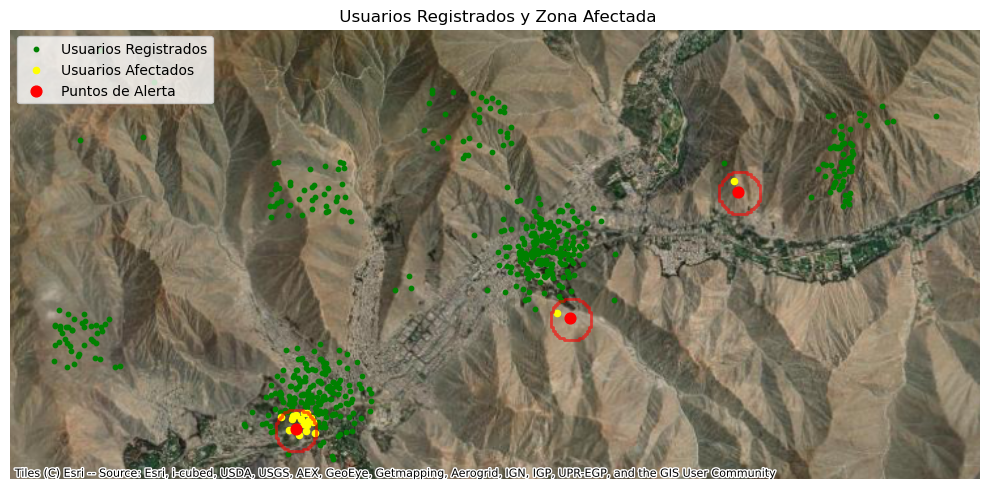

✅ CSV guardado en: ../results/usuarios_a_alertar_20250413_220205.csv


In [237]:
alertar_usuarios_desde_zona_maxima(fuente="ciudadano")  # o "camara"